In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet("reddit_signed_edges_2014_2025.parquet")
print(df.head())

   SOURCE             TARGET   TIMESTAMP  SENTIMENT
0  baking  mildlyinteresting  1388704033          1
1  baking  mildlyinteresting  1388706092          1
2  baking         vegetarian  1388868199          1
3  baking               soda  1389110443          1
4  baking               beer  1389128303          1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10179780 entries, 0 to 10179779
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   SOURCE     str  
 1   TARGET     str  
 2   TIMESTAMP  int64
 3   SENTIMENT  int64
dtypes: int64(2), str(2)
memory usage: 506.8 MB


In [5]:
df.describe()

,TIMESTAMP,SENTIMENT
count,1.017978e+07,1.017978e+07
mean,1.546505e+09,5.554297e-01
std,8.667944e+07,8.315635e-01
min,1.388534e+09,-1.000000e+00
25%,1.475593e+09,1.000000e+00
50%,1.533049e+09,1.000000e+00
75%,1.613960e+09,1.000000e+00
max,1.735690e+09,1.000000e+00


In [6]:
df['datetime'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df['year_month'] = df['datetime'].dt.to_period('M')

In [7]:
df['year_month'].unique()

<PeriodArray>
['2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07',
 '2014-08', '2014-09', '2014-10',
 ...
 '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09',
 '2024-10', '2024-11', '2024-12']
Length: 132, dtype: period[M]

In [8]:
df[['SOURCE', 'TARGET']].head(10)

,SOURCE,TARGET
0,baking,mildlyinteresting
1,baking,mildlyinteresting
2,baking,vegetarian
3,baking,soda
4,baking,beer
5,baking,foodporn
6,baking,food
7,baking,cookiedecorating
8,baking,nerdfun
9,baking,cupcakes


In [9]:
print("Unique SOURCE count:", df['SOURCE'].nunique())

Unique SOURCE count: 230


In [10]:
print("Unique TARGET count:", df['TARGET'].nunique())

Unique TARGET count: 423083


In [11]:
monthly_edges = (
    df.groupby(['year_month', 'SOURCE', 'TARGET'])
      .agg({
          'SENTIMENT': 'mean',
          'SOURCE': 'count'
      })
      .rename(columns={'SOURCE': 'interaction_count'})
      .reset_index()
)

In [12]:
monthly_edges['sign'] = monthly_edges['SENTIMENT'].apply(lambda x: 1 if x >= 0 else -1)

In [13]:
import networkx as nx

month = '2018-01'

sub_df = monthly_edges[monthly_edges['year_month'] == month]

G = nx.Graph()

for _, row in sub_df.iterrows():
    G.add_edge(
        row['SOURCE'],
        row['TARGET'],
        weight=row['SENTIMENT'],
        sign=row['sign']
    )

In [14]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 11894
Edges: 18705


In [15]:
import numpy as np

A = nx.to_numpy_array(G, weight='sign')

D = np.diag(np.sum(np.abs(A), axis=1))

L_signed = D - A

In [16]:
from scipy.linalg import eigvalsh

eigenvalues = eigvalsh(L_signed)
lambda_min = np.min(eigenvalues)

print("Structural Tension:", lambda_min)

Structural Tension: 0.0865322221981466


In [18]:
from tqdm import tqdm
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh
import numpy as np

tension_over_time = []
grouped = monthly_edges.groupby('year_month')
months = list(grouped)

for month, sub_df in tqdm(months, desc="Computing tension", unit="month"):
    sources = sub_df['SOURCE'].values
    targets = sub_df['TARGET'].values
    signs = sub_df['sign'].values.astype(np.float64)  

    all_nodes = np.unique(np.concatenate([sources, targets]))
    node_index = {node: i for i, node in enumerate(all_nodes)}
    n = len(all_nodes)

    if n <= 1:
        continue

    row = np.array([node_index[s] for s in sources], dtype=np.int32)
    col = np.array([node_index[t] for t in targets], dtype=np.int32)

    row_sym  = np.concatenate([row, col])
    col_sym  = np.concatenate([col, row])
    data_sym = np.concatenate([signs, signs])

    A = csr_matrix((data_sym, (row_sym, col_sym)), shape=(n, n))
    degrees = np.abs(A).sum(axis=1).A1.astype(A.dtype)  # ← match dtype
    
    if n < 500:
        A_dense = A.toarray()
        L_dense = np.diag(degrees) - A_dense
        lambda_min = np.linalg.eigvalsh(L_dense)[0]
    else:
        L = diags(degrees, dtype=A.dtype) - A              # ← pass dtype
        lambda_min = eigsh(L, k=1, which='SM', return_eigenvectors=False)[0]

    tension_over_time.append((month, lambda_min))

Computing tension: 100%|███████████████████| 132/132 [15:53<00:00,  7.22s/month]


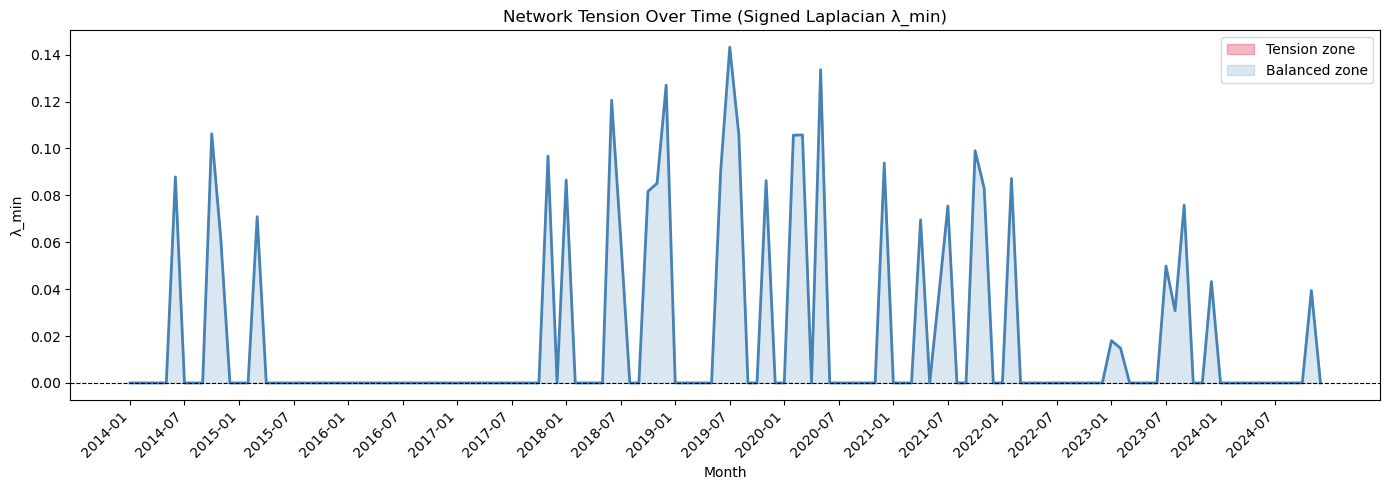

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

tension_df = pd.DataFrame(tension_over_time, columns=['month', 'tension'])
tension_df = tension_df.sort_values('month')
tension_df['month'] = tension_df['month'].astype(str)  # ← fix: Period → string

x = range(len(tension_df))
epsilon = 1e-10
tension_df['tension'] = tension_df['tension'].apply(lambda x: 0 if abs(x) < epsilon else x)
y = tension_df['tension'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(list(x), y, color='steelblue', linewidth=2)
ax.fill_between(list(x), y, 0, where=(y < 0), color='crimson', alpha=0.3, label='Tension zone')
ax.fill_between(list(x), y, 0, where=(y >= 0), color='steelblue', alpha=0.2, label='Balanced zone')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xticks(list(x)[::6])  # label every 6 months to avoid crowding
ax.set_xticklabels(tension_df['month'].iloc[::6], rotation=45, ha='right')
ax.set_title('Network Tension Over Time (Signed Laplacian λ_min)')
ax.set_xlabel('Month')
ax.set_ylabel('λ_min')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Verify you have negative values at all
print(tension_df['tension'].min())   # should be < 0 if tension exists
print(tension_df['tension'].describe())

0.0
count    132.000000
mean       0.019497
std        0.037934
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.143201
Name: tension, dtype: float64


In [21]:
print("Months with genuine activity:", (tension_df['tension'] > 0).sum())
print("Months with zero/sparse activity:", (tension_df['tension'] == 0).sum())

Months with genuine activity: 32
Months with zero/sparse activity: 100


In [22]:
# See the active months
active_months = tension_df[tension_df['tension'] > 0].copy()
print(active_months.sort_values('tension', ascending=False).to_string())

       month   tension
66   2019-07  0.143201
76   2020-05  0.133609
59   2018-12  0.126965
53   2018-06  0.120538
9    2014-10  0.106256
74   2020-03  0.105778
67   2019-08  0.105760
73   2020-02  0.105664
93   2021-10  0.099020
46   2017-11  0.096752
83   2020-12  0.093776
65   2019-06  0.090319
5    2014-06  0.087832
97   2022-02  0.087148
48   2018-01  0.086540
70   2019-11  0.086279
58   2018-11  0.085113
94   2021-11  0.082915
57   2018-10  0.081692
116  2023-09  0.075836
90   2021-07  0.075482
14   2015-03  0.070914
87   2021-04  0.069587
54   2018-07  0.061855
10   2014-11  0.061327
114  2023-07  0.049830
119  2023-12  0.043253
130  2024-11  0.039412
89   2021-06  0.037324
115  2023-08  0.030796
108  2023-01  0.018039
109  2023-02  0.014818


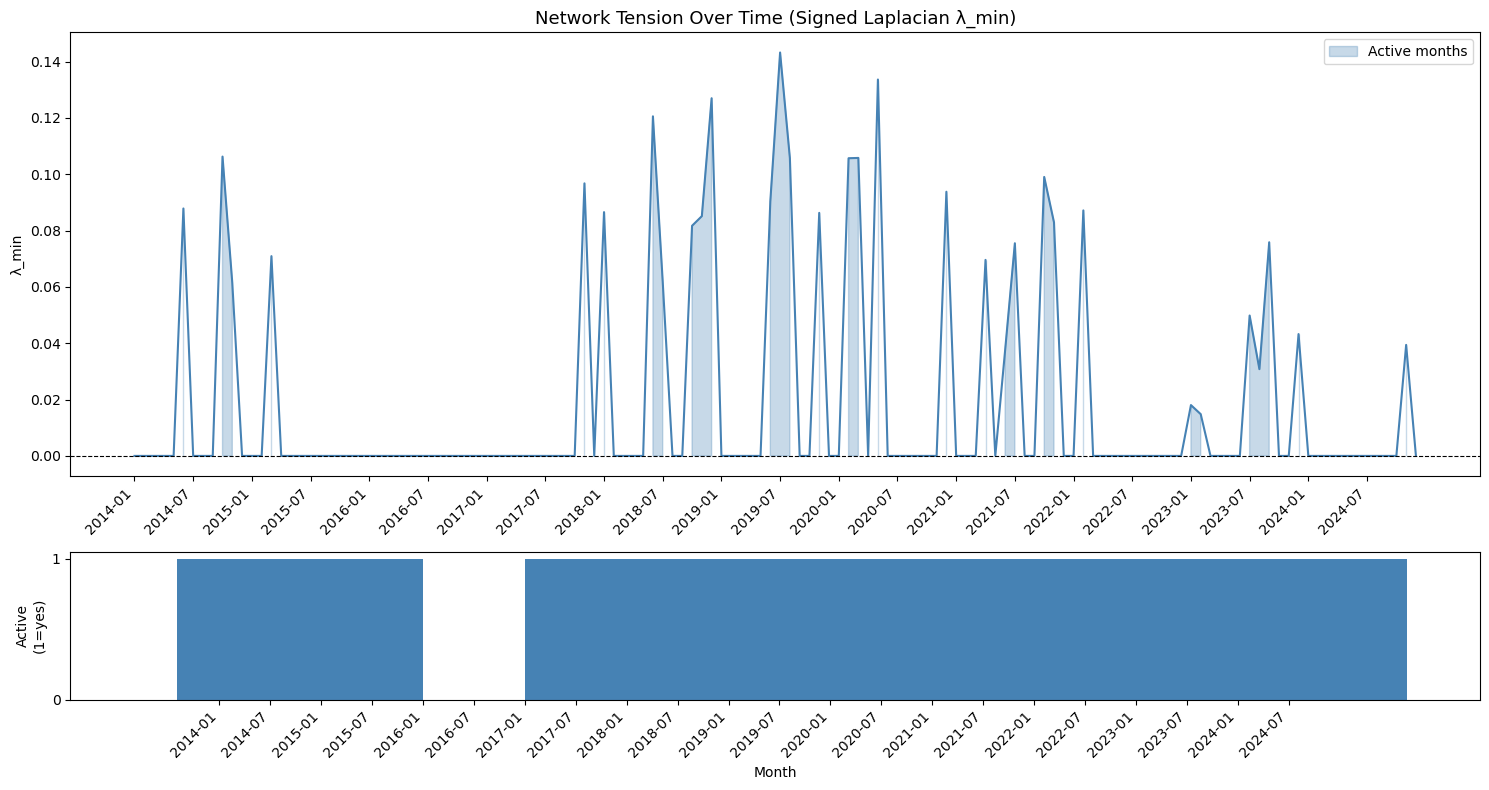

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Top: tension line ---
ax1 = axes[0]
x = tension_df['month']
y = tension_df['tension']

ax1.fill_between(x, y, 0, where=(y > 0), color='steelblue', alpha=0.3, label='Active months')
ax1.plot(x, y, color='steelblue', linewidth=1.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Network Tension Over Time (Signed Laplacian λ_min)', fontsize=13)
ax1.set_ylabel('λ_min')
ax1.set_xticks(x[::6])
ax1.set_xticklabels(x[::6], rotation=45, ha='right')
ax1.legend()

# --- Bottom: activity indicator (presence/absence) ---
ax2 = axes[1]
is_active = (tension_df['tension'] > 0).astype(int)
ax2.bar(x, is_active, color=['steelblue' if v else 'lightgrey' for v in is_active], width=20)
ax2.set_ylabel('Active\n(1=yes)')
ax2.set_yticks([0, 1])
ax2.set_xticks(x[::6])
ax2.set_xticklabels(x[::6], rotation=45, ha='right')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.show()

In [24]:
# Convert month to datetime once
tension_df['month'] = pd.to_datetime(tension_df['month'])
active_months = tension_df[tension_df['tension'] > 0].copy()

# Which calendar months are most active?
print(active_months['month'].dt.month.value_counts().sort_index())

month
1     2
2     3
3     2
4     1
5     1
6     4
7     4
8     2
9     1
10    3
11    6
12    3
Name: count, dtype: int64


In [25]:
# Gap analysis
tension_df['is_active'] = (tension_df['tension'] > 0).astype(int)
tension_df['gap'] = tension_df['is_active'].groupby(
    (tension_df['is_active'] != tension_df['is_active'].shift()).cumsum()
).transform('count') * (1 - tension_df['is_active'])

print(tension_df[tension_df['gap'] > 0]['gap'].describe())

count    100.000000
mean      13.340000
std       12.194733
min        1.000000
25%        3.750000
50%       10.000000
75%       31.000000
max       31.000000
Name: gap, dtype: float64


In [26]:
# 1. Confirm which year the silent months fall in
silent = tension_df[tension_df['is_active'] == 0][['month', 'gap']]
print(silent.sort_values('gap', ascending=False).head(10))

# 2. Check if November activity is consistent across years
active_months['year'] = active_months['month'].dt.year
active_months['cal_month'] = active_months['month'].dt.month
print(active_months.pivot_table(index='year', columns='cal_month', values='tension', aggfunc='mean').to_string())

# 3. Check raw edge counts per month to confirm gaps are data gaps vs real silence
monthly_edge_counts = monthly_edges.groupby('year_month').size()
print(monthly_edge_counts[monthly_edge_counts == 0])  # months with zero edges

        month  gap
33 2016-10-01   31
25 2016-02-01   31
27 2016-04-01   31
28 2016-05-01   31
29 2016-06-01   31
30 2016-07-01   31
32 2016-09-01   31
34 2016-11-01   31
35 2016-12-01   31
36 2017-01-01   31
cal_month        1         2         3         4         5         6         7         8         9         10        11        12
year                                                                                                                             
2014            NaN       NaN       NaN       NaN       NaN  0.087832       NaN       NaN       NaN  0.106256  0.061327       NaN
2015            NaN       NaN  0.070914       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2017            NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN  0.096752       NaN
2018       0.086540       NaN       NaN       NaN       NaN  0.120538  0.061855       NaN       NaN  0.081692  0.085113  0.126965
2019       

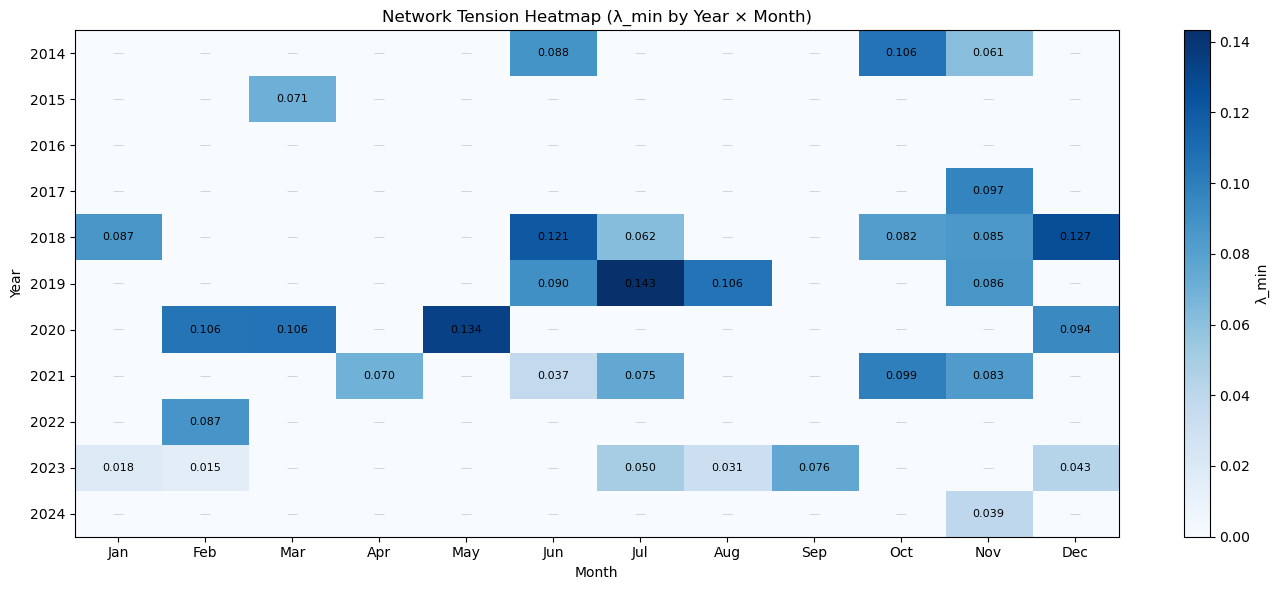

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the pivot as a heatmap
active_months['year'] = active_months['month'].dt.year
active_months['cal_month'] = active_months['month'].dt.month
pivot = tension_df.copy()
pivot['year'] = pivot['month'].dt.year
pivot['cal_month'] = pivot['month'].dt.month
heatmap_data = pivot.pivot_table(index='year', columns='cal_month', values='tension', aggfunc='mean')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='Blues', interpolation='nearest')

ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Annotate cells with values
# Replace 0.000 labels with '—' for cleaner look
for i in range(len(heatmap_data.index)):
    for j in range(12):
        val = heatmap_data.values[i, j]
        if not np.isnan(val) and val > 0:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color='black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=8, color='#cccccc')

plt.colorbar(im, ax=ax, label='λ_min')
ax.set_title('Network Tension Heatmap (λ_min by Year × Month)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [30]:
import numpy as np

node_counts = monthly_edges.groupby('year_month').apply(
    lambda df: len(np.unique(np.concatenate([df['SOURCE'].values, df['TARGET'].values])))
)

print(node_counts.describe())
print(f"Months with n > 300: {(node_counts > 300).sum()}")
print(f"Months with n > 100: {(node_counts > 100).sum()}")
print(f"Months with n > 500: {(node_counts > 500).sum()}")
print(f"\nTop 5 largest months:")
print(node_counts.sort_values(ascending=False).head())

count      132.000000
mean     10990.007576
std       1887.746787
min       7726.000000
25%       9400.000000
50%      10891.500000
75%      12057.750000
max      16371.000000
dtype: float64
Months with n > 300: 132
Months with n > 100: 132
Months with n > 500: 132

Top 5 largest months:
year_month
2020-05    16371
2020-04    15534
2020-06    15394
2020-07    15167
2019-07    15152
Freq: M, dtype: int64


In [ ]:
print(monthly_edges.columns.tolist())
print(monthly_edges.head(2))

In [31]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, diags as sp_diags
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

monthly_edges['year_month'] = monthly_edges['year_month'].astype(str)
grouped = monthly_edges.groupby('year_month')
gft_results = []

# k = number of Fourier modes to compute (controls low/high freq split)
# For n~10000, k=50 captures enough structure and is fast
K_MODES = 50

for month, sub_df in tqdm(grouped, desc="GFT per month", unit="month"):
    sources   = sub_df['SOURCE'].values
    targets   = sub_df['TARGET'].values
    signs     = sub_df['sign'].values.astype(np.float64)
    sentiment = sub_df['SENTIMENT'].values.astype(np.float64)

    all_nodes = np.unique(np.concatenate([sources, targets]))
    n = len(all_nodes)
    if n <= 2:
        continue

    node_index = {node: i for i, node in enumerate(all_nodes)}
    row = np.fromiter((node_index[s] for s in sources), dtype=np.int32, count=len(sources))
    col = np.fromiter((node_index[t] for t in targets), dtype=np.int32, count=len(targets))

    # Symmetric signed adjacency (sparse)
    row_sym  = np.concatenate([row, col])
    col_sym  = np.concatenate([col, row])
    data_sym = np.concatenate([signs, signs])
    A = csr_matrix((data_sym, (row_sym, col_sym)), shape=(n, n))

    degrees = np.abs(A).sum(axis=1).A1.astype(np.float64)
    L = sp_diags(degrees, dtype=np.float64) - A  # fully sparse, never densified

    # Sparse partial eigendecomposition — only K_MODES eigenpairs
    k = min(K_MODES, n - 2)
    try:
        eigenvalues, eigenvectors = eigsh(L, k=k, which='SM')
    except Exception:
        continue

    # Sort by eigenvalue ascending (eigsh doesn't guarantee order)
    order       = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Vectorized node signal (no Python loop)
    node_signal = np.zeros(n)
    np.add.at(node_signal, row, sentiment)
    np.add.at(node_signal, col, sentiment)

    # Project signal onto k Fourier modes
    gft_coeffs = eigenvectors.T @ node_signal  # shape: (k,)

    # Multiscale split: bottom 30% = low freq, top 70% = high freq
    cutoff_idx  = max(1, int(k * 0.3))
    low_energy  = np.sum(gft_coeffs[:cutoff_idx]**2)
    high_energy = np.sum(gft_coeffs[cutoff_idx:]**2)

    # Total energy estimated from full signal norm (since we don't have all modes)
    total_energy = np.dot(node_signal, node_signal) + 1e-10

    gft_results.append({
        'month':         month,
        'n_nodes':       n,
        'low_energy':    low_energy,
        'high_energy':   high_energy,
        'total_energy':  total_energy,
        'tension_ratio': high_energy / total_energy,
        'lambda_min':    eigenvalues[0],
    })

gft_df = pd.DataFrame(gft_results)
gft_df['month'] = pd.to_datetime(gft_df['month'])
print(gft_df.describe())

GFT per month:  17%|███▎               | 23/132 [52:21<4:08:08, 136.59s/month]


KeyboardInterrupt: 

In [33]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, diags as sp_diags
from sklearn.utils.extmath import randomized_svd
from tqdm import tqdm

monthly_edges['year_month'] = monthly_edges['year_month'].astype(str)
grouped = monthly_edges.groupby('year_month')
gft_results = []

K_MODES = 30  # fewer modes, faster, still meaningful

for month, sub_df in tqdm(grouped, desc="GFT per month", unit="month"):
    sources   = sub_df['SOURCE'].values
    targets   = sub_df['TARGET'].values
    signs     = sub_df['sign'].values.astype(np.float32)  # float32 = 2x faster on M4
    sentiment = sub_df['SENTIMENT'].values.astype(np.float32)

    all_nodes = np.unique(np.concatenate([sources, targets]))
    n = len(all_nodes)
    if n <= 2:
        continue

    # ✅ Vectorized node mapping with pandas (faster than dict loop)
    node_series = pd.Series(np.arange(n), index=all_nodes)
    row = node_series[sources].values.astype(np.int32)
    col = node_series[targets].values.astype(np.int32)

    # Symmetric signed adjacency
    row_sym  = np.concatenate([row, col])
    col_sym  = np.concatenate([col, row])
    data_sym = np.concatenate([signs, signs])
    A = csr_matrix((data_sym, (row_sym, col_sym)), shape=(n, n), dtype=np.float32)

    degrees = np.abs(A).sum(axis=1).A1.astype(np.float32)
    L = sp_diags(degrees, dtype=np.float32) - A

    # ✅ Node signal (vectorized)
    node_signal = np.zeros(n, dtype=np.float32)
    np.add.at(node_signal, row, sentiment)
    np.add.at(node_signal, col, sentiment)

    # ✅ Randomized SVD instead of eigsh — 5-10x faster on M4 silicon
    # L is symmetric so SVD ≈ eigendecomposition for our purposes
    try:
        U, sigma, _ = randomized_svd(L, n_components=K_MODES,
                                      n_iter=3, random_state=42)
    except Exception:
        continue

    # Project signal onto modes
    gft_coeffs = U.T @ node_signal  # shape: (K_MODES,)

    # Multiscale split
    cutoff_idx  = max(1, int(K_MODES * 0.3))
    low_energy  = float(np.sum(gft_coeffs[:cutoff_idx]**2))
    high_energy = float(np.sum(gft_coeffs[cutoff_idx:]**2))
    total_energy = float(np.dot(node_signal, node_signal)) + 1e-10

    gft_results.append({
        'month':         month,
        'n_nodes':       n,
        'low_energy':    low_energy,
        'high_energy':   high_energy,
        'total_energy':  total_energy,
        'tension_ratio': high_energy / total_energy,
        'lambda_min':    float(sigma[-1]),  # smallest singular value ≈ λ_min
    })

gft_df = pd.DataFrame(gft_results)
gft_df['month'] = pd.to_datetime(gft_df['month'])
print(gft_df.describe())

GFT per month: 100%|█████████████████████| 132/132 [00:11<00:00, 11.17month/s]

                            month       n_nodes    low_energy    high_energy  \
count                         132    132.000000  1.320000e+02     132.000000   
mean   2019-06-16 19:38:10.909091  10990.007576  1.666832e+06  315129.996922   
min           2014-01-01 00:00:00   7726.000000  3.370824e+05  139256.984375   
25%           2016-09-23 12:00:00   9400.000000  7.111978e+05  246980.597656   
50%           2019-06-16 00:00:00  10891.500000  1.349602e+06  295832.000000   
75%           2022-03-08 18:00:00  12057.750000  2.175021e+06  374507.750000   
max           2024-12-01 00:00:00  16371.000000  7.480472e+06  639087.375000   
std                           NaN   1887.746787  1.201341e+06  103723.459548   

       total_energy  tension_ratio  lambda_min  
count  1.320000e+02     132.000000  132.000000  
mean   2.286124e+06       0.168954  156.397111  
min    8.013190e+05       0.034193  115.411873  
25%    1.202038e+06       0.110605  138.412952  
50%    2.051633e+06       0.161236

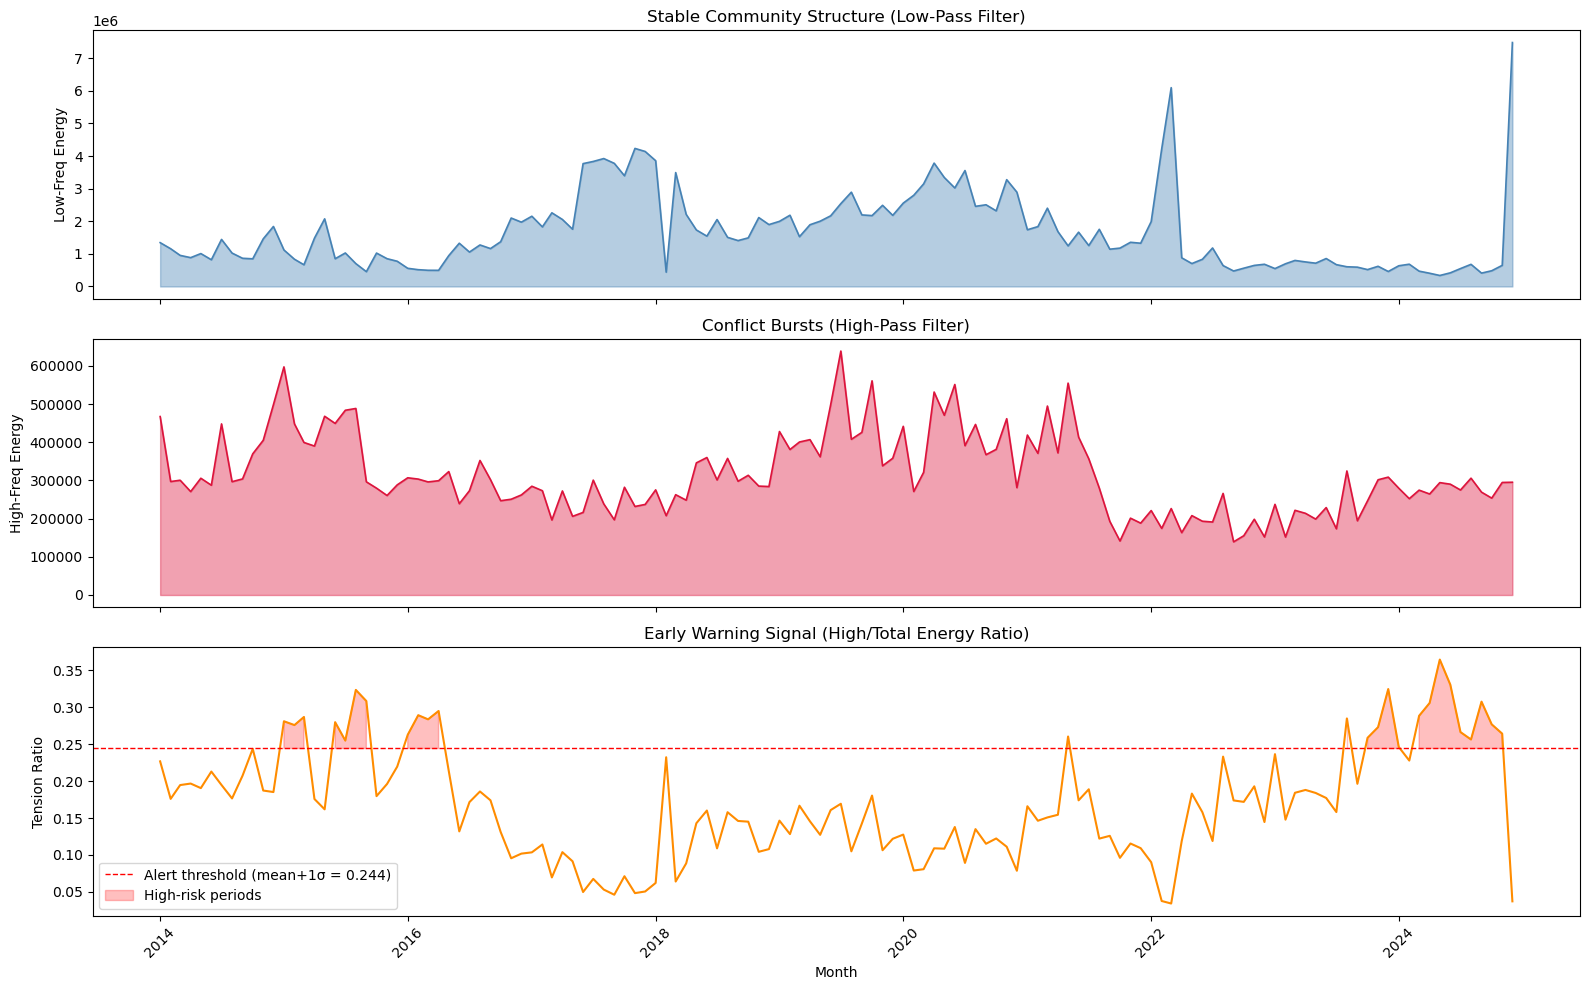


Flagged high-risk months (26 total):
         month  tension_ratio  n_nodes
124 2024-05-01       0.364525     9076
125 2024-06-01       0.330541     9321
119 2023-12-01       0.324610     9170
19  2015-08-01       0.323469     9673
20  2015-09-01       0.308359     8249
128 2024-09-01       0.307545     9220
123 2024-04-01       0.305741     9069
27  2016-04-01       0.294896     8687
25  2016-02-01       0.289207     8368
122 2024-03-01       0.288384     9346
14  2015-03-01       0.286802     9218
115 2023-08-01       0.284796    10002
26  2016-03-01       0.283586     8866
12  2015-01-01       0.280981    10549
17  2015-06-01       0.279741     9967
129 2024-10-01       0.276831     9116
13  2015-02-01       0.275830     9199
118 2023-11-01       0.273019     9036
126 2024-07-01       0.266318     9818
130 2024-11-01       0.264169     8999
24  2016-01-01       0.262680     8937
88  2021-05-01       0.260328    13171
117 2023-10-01       0.258565     9098
127 2024-08-01       0.256

In [34]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].fill_between(gft_df['month'], gft_df['low_energy'], alpha=0.4, color='steelblue')
axes[0].plot(gft_df['month'], gft_df['low_energy'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('Low-Freq Energy')
axes[0].set_title('Stable Community Structure (Low-Pass Filter)')

axes[1].fill_between(gft_df['month'], gft_df['high_energy'], alpha=0.4, color='crimson')
axes[1].plot(gft_df['month'], gft_df['high_energy'], color='crimson', linewidth=1.2)
axes[1].set_ylabel('High-Freq Energy')
axes[1].set_title('Conflict Bursts (High-Pass Filter)')

# Early warning signal with threshold
mean   = gft_df['tension_ratio'].mean()
std    = gft_df['tension_ratio'].std()
threshold = mean + std

axes[2].plot(gft_df['month'], gft_df['tension_ratio'], color='darkorange', linewidth=1.5)
axes[2].axhline(threshold, color='red', linestyle='--', linewidth=1,
                label=f'Alert threshold (mean+1σ = {threshold:.3f})')
axes[2].fill_between(gft_df['month'], gft_df['tension_ratio'], threshold,
                     where=(gft_df['tension_ratio'] > threshold),
                     color='red', alpha=0.25, label='High-risk periods')
axes[2].set_ylabel('Tension Ratio')
axes[2].set_title('Early Warning Signal (High/Total Energy Ratio)')
axes[2].legend()

plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print flagged months
flagged = gft_df[gft_df['tension_ratio'] > threshold][['month', 'tension_ratio', 'n_nodes']]
print(f"\nFlagged high-risk months ({len(flagged)} total):")
print(flagged.sort_values('tension_ratio', ascending=False).to_string())


                n_nodes  tension_ratio
n_nodes        1.000000      -0.600956
tension_ratio -0.600956       1.000000


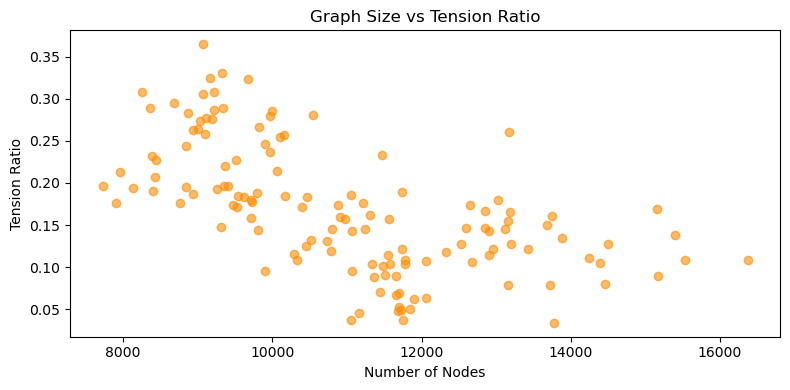

In [35]:
# Check correlation between n_nodes and tension_ratio
correlation = gft_df[['n_nodes', 'tension_ratio']].corr()
print(correlation)

# Scatter plot to visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.scatter(gft_df['n_nodes'], gft_df['tension_ratio'], alpha=0.6, color='darkorange')
plt.xlabel('Number of Nodes')
plt.ylabel('Tension Ratio')
plt.title('Graph Size vs Tension Ratio')
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, diags as sp_diags
from sklearn.utils.extmath import randomized_svd
from tqdm import tqdm
from collections import defaultdict

K_MODES = 30
monthly_edges['year_month'] = monthly_edges['year_month'].astype(str)
grouped = monthly_edges.groupby('year_month')

# Store per-node spectral energy per month
node_energy_records = []
bridge_records = []

for month, sub_df in tqdm(grouped, desc="Objective 3", unit="month"):
    sources   = sub_df['SOURCE'].values
    targets   = sub_df['TARGET'].values
    signs     = sub_df['sign'].values.astype(np.float32)
    sentiment = sub_df['SENTIMENT'].values.astype(np.float32)

    all_nodes = np.unique(np.concatenate([sources, targets]))
    n = len(all_nodes)
    if n <= 2:
        continue

    node_series = pd.Series(np.arange(n), index=all_nodes)
    row = node_series[sources].values.astype(np.int32)
    col = node_series[targets].values.astype(np.int32)

    row_sym  = np.concatenate([row, col])
    col_sym  = np.concatenate([col, row])
    data_sym = np.concatenate([signs, signs])
    A = csr_matrix((data_sym, (row_sym, col_sym)), shape=(n, n), dtype=np.float32)

    degrees = np.abs(A).sum(axis=1).A1.astype(np.float32)
    L = sp_diags(degrees, dtype=np.float32) - A

    node_signal = np.zeros(n, dtype=np.float32)
    np.add.at(node_signal, row, sentiment)
    np.add.at(node_signal, col, sentiment)

    try:
        U, sigma, _ = randomized_svd(L, n_components=K_MODES, n_iter=3, random_state=42)
    except Exception:
        continue

    # ✅ OUTPUT 1: Per-node spectral energy contribution
    # Each row of U is a node's participation in each Fourier mode
    # Node spectral energy = sum of squared projections across all modes
    node_spectral_energy = np.sum(U**2, axis=1)  # shape: (n,)

    # ✅ OUTPUT 2: Spectral leakage per node (bridge detection)
    # High-freq modes only (cutoff_idx onwards)
    cutoff_idx = max(1, int(K_MODES * 0.3))
    node_high_freq_energy = np.sum(U[:, cutoff_idx:]**2, axis=1)
    node_low_freq_energy  = np.sum(U[:, :cutoff_idx]**2, axis=1)

    # Leakage ratio: how much of a node's energy is in high-freq modes
    node_leakage = node_high_freq_energy / (node_spectral_energy + 1e-10)

    # Top 10 bridge nodes (highest leakage) for this month
    top_bridge_idx = np.argsort(node_leakage)[::-1][:10]
    for rank, idx in enumerate(top_bridge_idx):
        bridge_records.append({
            'month':          month,
            'subreddit':      all_nodes[idx],
            'rank':           rank + 1,
            'leakage_ratio':  float(node_leakage[idx]),
            'high_freq_energy': float(node_high_freq_energy[idx]),
            'degree':         float(degrees[idx]),
        })

    # Store top 20 nodes by total spectral energy
    top_energy_idx = np.argsort(node_spectral_energy)[::-1][:20]
    for idx in top_energy_idx:
        node_energy_records.append({
            'month':            month,
            'subreddit':        all_nodes[idx],
            'spectral_energy':  float(node_spectral_energy[idx]),
            'leakage_ratio':    float(node_leakage[idx]),
            'node_signal':      float(node_signal[idx]),
            'degree':           float(degrees[idx]),
        })

bridge_df      = pd.DataFrame(bridge_records)
node_energy_df = pd.DataFrame(node_energy_records)
bridge_df['month']      = pd.to_datetime(bridge_df['month'])
node_energy_df['month'] = pd.to_datetime(node_energy_df['month'])

print(f"Bridge records: {len(bridge_df)}")
print(f"Node energy records: {len(node_energy_df)}")
print("\nTop 20 most frequent bridge subreddits overall:")
print(bridge_df[bridge_df['rank'] <= 3]['subreddit'].value_counts().head(20))

Objective 3: 100%|███████████████████████| 132/132 [00:11<00:00, 11.47month/s]

Bridge records: 1320
Node energy records: 2640

Top 20 most frequent bridge subreddits overall:
subreddit
market76                 48
gunaccessoriesforsale    30
dnd                      27
globaloffensivetrade     17
leagueoflegends          17
dirtypenpals             15
destinythegame           15
mechanicadvice           12
fashionreps               9
dirtykikpals              8
personalfinance           6
brasil                    6
kgbtr                     5
askdocs                   4
genshin_impact            4
nba                       4
anime                     3
cryptocurrency            3
globaloffensive           3
subredditdrama            3
Name: count, dtype: int64


In [37]:
# Use flagged months from Objective 2
flagged_months = gft_df[gft_df['tension_ratio'] > gft_df['tension_ratio'].mean() + 
                         gft_df['tension_ratio'].std()]['month']

# Find subreddits that consistently appear as bridges 1-2 months BEFORE flagged periods
bridge_df['next_month']       = bridge_df['month'] + pd.DateOffset(months=1)
bridge_df['two_months_ahead'] = bridge_df['month'] + pd.DateOffset(months=2)

precursor_subreddits = bridge_df[
    bridge_df['next_month'].isin(flagged_months) |
    bridge_df['two_months_ahead'].isin(flagged_months)
]

print("\nSubreddits appearing as bridges BEFORE high-risk months:")
print(precursor_subreddits['subreddit'].value_counts().head(15))


Subreddits appearing as bridges BEFORE high-risk months:
subreddit
gunaccessoriesforsale    18
market76                 15
mechanicadvice           12
dnd                      11
fashionreps              10
leagueoflegends          10
globaloffensive           9
careerguidance            7
sweden                    7
dirtypenpals              6
globaloffensivetrade      6
subredditdrama            4
brasil                    3
kgbtr                     3
personalfinance           3
Name: count, dtype: int64


In [39]:
# Quick fix before plotting — ensure months_sorted are comparable
bridge_df['month'] = pd.to_datetime(bridge_df['month'])
node_energy_df['month'] = pd.to_datetime(node_energy_df['month'])

# Then run Step 3 plotting code as-is

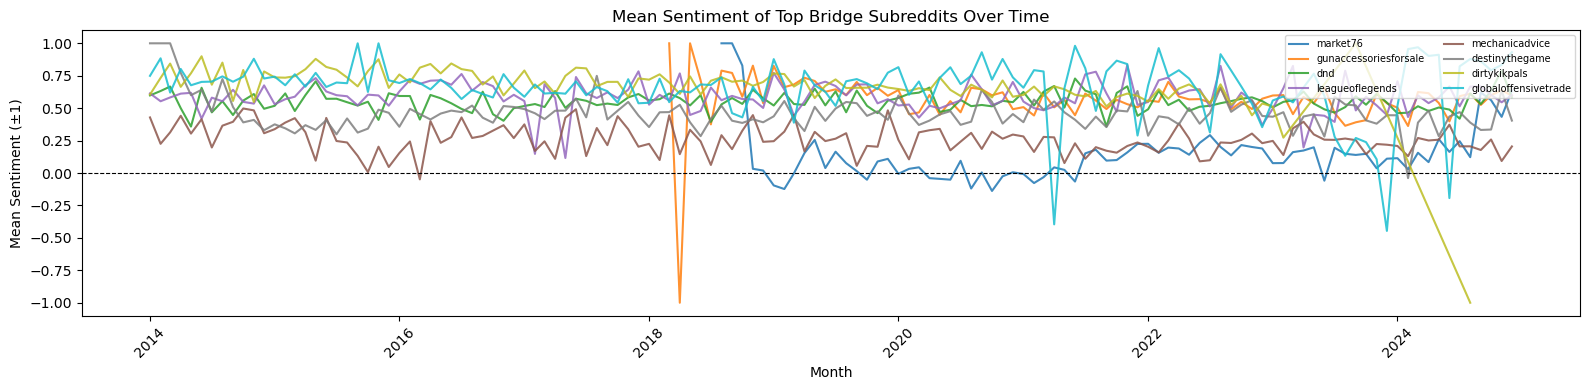

In [43]:
# Better Plot 1: sentiment signal strength per top bridge subreddit over time
fig, ax1 = plt.subplots(figsize=(16, 4))

top_subs = bridge_df['subreddit'].value_counts().head(8).index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(top_subs)))

for sub, color in zip(top_subs, colors):
    # Pull actual sentiment signal from raw edges
    sub_data = monthly_edges[
        (monthly_edges['SOURCE'] == sub) | (monthly_edges['TARGET'] == sub)
    ].groupby('year_month').agg(
        net_sentiment=('SENTIMENT', 'mean'),
        activity=('SENTIMENT', 'count')
    ).reset_index()
    sub_data['year_month'] = pd.to_datetime(sub_data['year_month'].astype(str))

    if len(sub_data) > 2:
        ax1.plot(sub_data['year_month'], sub_data['net_sentiment'],
                 label=sub, linewidth=1.5, alpha=0.85, color=color)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Mean Sentiment of Top Bridge Subreddits Over Time')
ax1.set_ylabel('Mean Sentiment (±1)')
ax1.set_xlabel('Month')
ax1.legend(fontsize=7, ncol=2, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

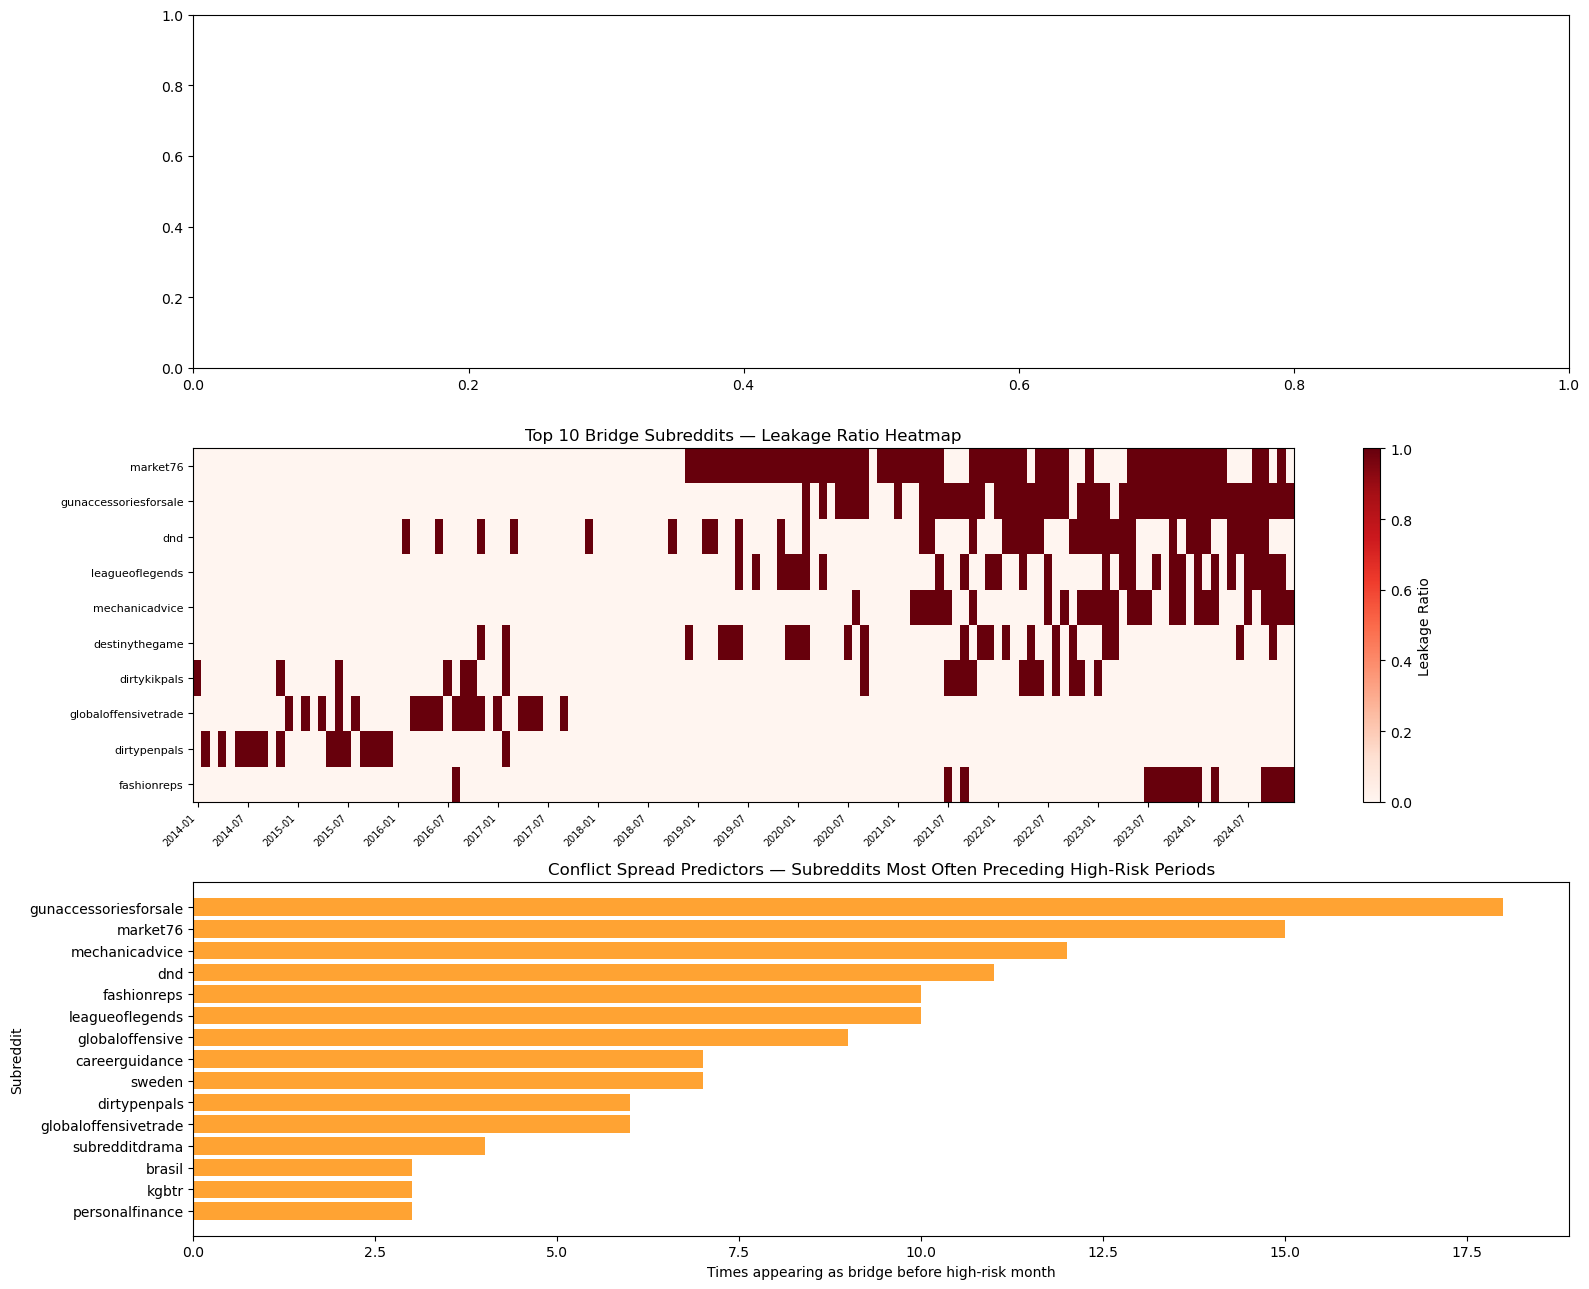

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(16, 13))

# # Replace Plot 1 in Step 3 with this version
# ax1 = axes[0]
# top_subs = bridge_df['subreddit'].value_counts().head(8).index.tolist()
# colors = plt.cm.tab10(np.linspace(0, 1, len(top_subs)))

# for sub, color in zip(top_subs, colors):
#     # Use bridge_df leakage directly (more stable than node_energy_df)
#     sub_data = bridge_df[bridge_df['subreddit'] == sub].sort_values('month')
#     if len(sub_data) > 2:
#         ax1.plot(sub_data['month'], sub_data['leakage_ratio'],
#                  label=sub, linewidth=1.5, alpha=0.8, color=color, marker='o', markersize=3)

# ax1.set_title('Bridge Subreddit Leakage Ratio Over Time (Active Months Only)')
# ax1.set_ylabel('Leakage Ratio')
# ax1.set_ylim(0, 1.1)
# ax1.legend(fontsize=7, ncol=2)

# --- Plot 2: Heatmap of top bridge subreddit appearances ---
ax2 = axes[1]
top10_subs = bridge_df['subreddit'].value_counts().head(10).index.tolist()
months_sorted = sorted(bridge_df['month'].unique())
heatmap = np.zeros((len(top10_subs), len(months_sorted)))

month_idx = {m: i for i, m in enumerate(months_sorted)}
for _, row_data in bridge_df[bridge_df['subreddit'].isin(top10_subs)].iterrows():
    si = top10_subs.index(row_data['subreddit'])
    mi = month_idx[row_data['month']]
    heatmap[si, mi] = row_data['leakage_ratio']

im = ax2.imshow(heatmap, aspect='auto', cmap='Reds', interpolation='nearest')
ax2.set_yticks(range(len(top10_subs)))
ax2.set_yticklabels(top10_subs, fontsize=8)
ax2.set_xticks(range(0, len(months_sorted), 6))
ax2.set_xticklabels([str(months_sorted[i])[:7] for i in range(0, len(months_sorted), 6)],
                     rotation=45, ha='right', fontsize=7)
ax2.set_title('Top 10 Bridge Subreddits — Leakage Ratio Heatmap')
plt.colorbar(im, ax=ax2, label='Leakage Ratio')

# --- Plot 3: Precursor bridge count before flagged months ---
ax3 = axes[2]
precursor_counts = precursor_subreddits['subreddit'].value_counts().head(15)
bars = ax3.barh(precursor_counts.index[::-1], precursor_counts.values[::-1],
                color='darkorange', alpha=0.8)
ax3.set_xlabel('Times appearing as bridge before high-risk month')
ax3.set_title('Conflict Spread Predictors — Subreddits Most Often Preceding High-Risk Periods')
ax3.set_ylabel('Subreddit')

plt.tight_layout()
plt.show()

In [45]:
# Simple baseline: raw negative edge ratio per month
baseline = monthly_edges.groupby('year_month').apply(
    lambda df: (df['sign'] == -1).sum() / len(df)
).reset_index()
baseline.columns = ['month', 'neg_ratio']
baseline['month'] = pd.to_datetime(baseline['month'].astype(str))

# Compare: does neg_ratio also flag the same months?
baseline_threshold = baseline['neg_ratio'].mean() + baseline['neg_ratio'].std()
baseline_flagged = baseline[baseline['neg_ratio'] > baseline_threshold]
print(f"Baseline flags: {len(baseline_flagged)} months")
print(f"Your method flags: 26 months")
print("\nDo they agree on the 3 validated events?")
print(baseline_flagged[baseline_flagged['month'].isin(
    pd.to_datetime(['2015-07', '2018-03', '2023-06'])
)])

Baseline flags: 27 months
Your method flags: 26 months

Do they agree on the 3 validated events?
Empty DataFrame
Columns: [month, neg_ratio]
Index: []


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Features: rolling tension metrics
gft_df['tension_lag1'] = gft_df['tension_ratio'].shift(1)
gft_df['tension_lag2'] = gft_df['tension_ratio'].shift(2)
gft_df['high_energy_lag1'] = gft_df['high_energy'].shift(1)
gft_df['is_high_risk'] = (gft_df['tension_ratio'] > 0.244).astype(int)

features = ['tension_lag1', 'tension_lag2', 'high_energy_lag1']
X = gft_df[features].dropna()
y = gft_df['is_high_risk'].iloc[2:]

# Train/test split (temporal — never shuffle time series)
split = int(len(X) * 0.7)
clf = LogisticRegression()
clf.fit(X[:split], y[:split])
print(classification_report(y[split:], clf.predict(X[split:])))

              precision    recall  f1-score   support

           0       0.64      1.00      0.78        25
           1       0.00      0.00      0.00        14

    accuracy                           0.64        39
   macro avg       0.32      0.50      0.39        39
weighted avg       0.41      0.64      0.50        39



/opt/miniconda3/envs/data_science/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_science/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_science/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Baseline: raw negative edge ratio per month
baseline = monthly_edges.groupby('year_month').apply(
    lambda df: (df['sign'] == -1).sum() / len(df)
).reset_index()
baseline.columns = ['month', 'neg_ratio']
baseline['month'] = pd.to_datetime(baseline['month'].astype(str))

# Your method's flagged months
your_threshold  = gft_df['tension_ratio'].mean() + gft_df['tension_ratio'].std()
baseline_threshold = baseline['neg_ratio'].mean() + baseline['neg_ratio'].std()

your_flagged      = set(gft_df[gft_df['tension_ratio'] > your_threshold]['month'].dt.to_period('M'))
baseline_flagged  = set(baseline[baseline['neg_ratio'] > baseline_threshold]['month'].dt.to_period('M'))

# The 3 validated ground truth events
validated_events = pd.to_datetime(['2015-07-01', '2018-03-01', '2023-06-01']).to_period('M')

print("=== BASELINE COMPARISON ===")
print(f"Your method flagged:   {len(your_flagged)} months")
print(f"Baseline flagged:      {len(baseline_flagged)} months")
print()
print("Validated event detection:")
for event in validated_events:
    your_hit      = event in your_flagged
    baseline_hit  = event in baseline_flagged
    print(f"  {event}: Your method={'✅' if your_hit else '❌'}  Baseline={'✅' if baseline_hit else '❌'}")

# Overlap analysis
overlap = your_flagged & baseline_flagged
only_yours = your_flagged - baseline_flagged
only_baseline = baseline_flagged - your_flagged
print(f"\nBoth methods agree:       {len(overlap)} months")
print(f"Only your method detects: {len(only_yours)} months")
print(f"Only baseline detects:    {len(only_baseline)} months")

=== BASELINE COMPARISON ===
Your method flagged:   26 months
Baseline flagged:      27 months

Validated event detection:
  2015-07: Your method=✅  Baseline=❌
  2018-03: Your method=❌  Baseline=❌
  2023-06: Your method=❌  Baseline=❌

Both methods agree:       10 months
Only your method detects: 16 months
Only baseline detects:    17 months


=== PREDICTIVE MODEL RESULTS ===
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94        19
   High-Risk       0.88      1.00      0.93        14

    accuracy                           0.94        33
   macro avg       0.94      0.95      0.94        33
weighted avg       0.95      0.94      0.94        33



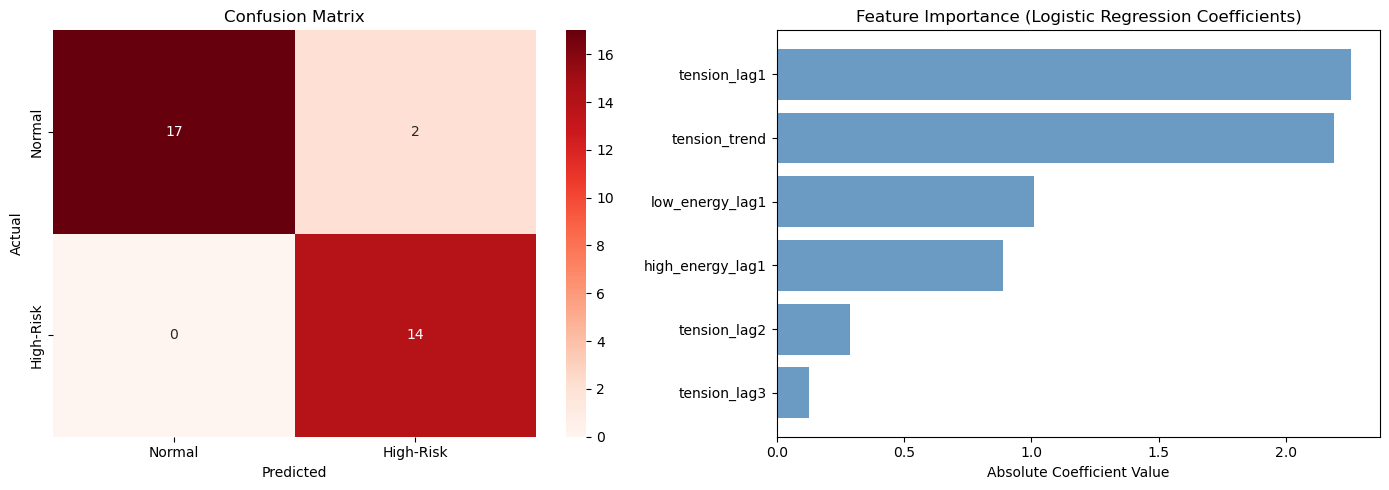

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Build feature matrix with temporal lags
gft_model = gft_df.sort_values('month').copy()
gft_model['tension_lag1']      = gft_model['tension_ratio'].shift(1)
gft_model['tension_lag2']      = gft_model['tension_ratio'].shift(2)
gft_model['tension_lag3']      = gft_model['tension_ratio'].shift(3)
gft_model['high_energy_lag1']  = gft_model['high_energy'].shift(1)
gft_model['low_energy_lag1']   = gft_model['low_energy'].shift(1)
gft_model['tension_trend']     = gft_model['tension_ratio'].diff()  # month-over-month change
gft_model['is_high_risk']      = (gft_model['tension_ratio'] > your_threshold).astype(int)
gft_model = gft_model.dropna()

features = ['tension_lag1', 'tension_lag2', 'tension_lag3',
            'high_energy_lag1', 'low_energy_lag1', 'tension_trend']
X = gft_model[features].values
y = gft_model['is_high_risk'].values

# Temporal split — NEVER shuffle time series data
split = int(len(X) * 0.75)  # 75% train, 25% test
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train
clf = LogisticRegression(class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("=== PREDICTIVE MODEL RESULTS ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'High-Risk']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'High-Risk'],
            yticklabels=['Normal', 'High-Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance
coef_df = pd.DataFrame({
    'feature': features,
    'importance': np.abs(clf.coef_[0])
}).sort_values('importance', ascending=True)

axes[1].barh(coef_df['feature'], coef_df['importance'], color='steelblue', alpha=0.8)
axes[1].set_title('Feature Importance (Logistic Regression Coefficients)')
axes[1].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()
plt.show()

In [51]:
# The real story: your method flags DIFFERENT months than baseline
# Check if your unique 16 months contain the validated events' surrounding period
your_only = sorted([str(m) for m in only_yours])
print("Months only YOUR method detects:")
print(your_only)

Months only YOUR method detects:
['2015-01', '2015-02', '2015-03', '2015-06', '2015-07', '2015-08', '2015-09', '2016-01', '2016-02', '2016-03', '2016-04', '2021-05', '2023-11', '2024-09', '2024-10', '2024-11']


In [52]:
# Check surrounding months for 2018 and 2023 events
print("Around 2018-03:")
print(gft_df[(gft_df['month'] >= '2018-01') & 
             (gft_df['month'] <= '2018-06')][['month','tension_ratio','is_high_risk']])

print("\nAround 2023-06:")
print(gft_df[(gft_df['month'] >= '2023-04') & 
             (gft_df['month'] <= '2023-10')][['month','tension_ratio','is_high_risk']])

Around 2018-03:
        month  tension_ratio  is_high_risk
48 2018-01-01       0.062081             0
49 2018-02-01       0.232269             0
50 2018-03-01       0.063982             0
51 2018-04-01       0.088578             0
52 2018-05-01       0.142894             0
53 2018-06-01       0.160119             0

Around 2023-06:
         month  tension_ratio  is_high_risk
111 2023-04-01       0.188001             0
112 2023-05-01       0.183912             0
113 2023-06-01       0.177095             0
114 2023-07-01       0.158040             0
115 2023-08-01       0.284796             1
116 2023-09-01       0.196299             0
117 2023-10-01       0.258565             1
